# Insurance Claims Analysis

A Python-based data analysis project exploring automobile insurance claims, risk characteristics, and patterns in claim outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

## Dataset

This project uses an anonymized Spanish motor insurance portfolio dataset. Each row represents a policy-period.

## Data Loading and Inspection

In [2]:
df = pd.read_csv(
    "Dataset of an actual motor vehicle insurance portfolio/Motor vehicle insurance data.csv",
    sep=";"
)

df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


In [3]:
df.shape

(105555, 30)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    105555 non-null  int64  
 1   Date_start_contract   105555 non-null  str    
 2   Date_last_renewal     105555 non-null  str    
 3   Date_next_renewal     105555 non-null  str    
 4   Date_birth            105555 non-null  str    
 5   Date_driving_licence  105555 non-null  str    
 6   Distribution_channel  105555 non-null  int64  
 7   Seniority             105555 non-null  int64  
 8   Policies_in_force     105555 non-null  int64  
 9   Max_policies          105555 non-null  int64  
 10  Max_products          105555 non-null  int64  
 11  Lapse                 105555 non-null  int64  
 12  Date_lapse            35147 non-null   str    
 13  Payment               105555 non-null  int64  
 14  Premium               105555 non-null  float64
 15  Cost_claims

In [5]:
missing = df.isna().sum()
missing[missing > 0]

Date_lapse    70408
Type_fuel      1764
Length        10329
dtype: int64

## Data Preparation

Categorical codes were interpreted using the data dictionary provided with the original dataset.

In [6]:
analysis_columns = [
    "Premium",
    "Cost_claims_year",
    "N_claims_year",
    "Type_risk",
    "Area"
]

analysis_df = df[analysis_columns].copy()

analysis_df.head()

,Premium,Cost_claims_year,N_claims_year,Type_risk,Area
0,222.52,0.0,0,1,0
1,213.78,0.0,0,1,0
2,214.84,0.0,0,1,0
3,216.99,0.0,0,1,0
4,213.70,0.0,0,1,0


In [7]:
# Check categorical codes before recoding
analysis_df["Type_risk"].value_counts()

Type_risk
3    82990
2    13212
1     8502
4      851
Name: count, dtype: int64

In [8]:
# Check categorical codes before recoding
analysis_df["Area"].value_counts()

Area
0    76644
1    28911
Name: count, dtype: int64

In [9]:
# Replace categorical codes with descriptive labels
analysis_df["Type_risk"] = analysis_df["Type_risk"].replace({
    1: "Motorbike",
    2: "Van",
    3: "Passenger car",
    4: "Agricultural vehicle"
})

analysis_df["Area"] = analysis_df["Area"].replace({
    0: "Rural",
    1: "Urban"
})

In [10]:
# Identify policy-periods with at least one claim
analysis_df["Had_claim"] = analysis_df["N_claims_year"] > 0

In [11]:
# Check summary statistics for numerical variables
analysis_df[["Premium", "Cost_claims_year", "N_claims_year"]].describe()

,Premium,Cost_claims_year,N_claims_year
count,105555.000000,105555.000000,105555.000000
mean,315.892557,153.557305,0.394695
std,140.927969,1477.112362,1.105018
min,40.140000,0.000000,0.000000
25%,241.610000,0.000000,0.000000
50%,292.280000,0.000000,0.000000
75%,361.640000,0.000000,0.000000
max,2993.340000,260853.240000,25.000000


In [12]:
# Check consistency between claim counts and claim costs
analysis_df[
    ((analysis_df["N_claims_year"] == 0) & (analysis_df["Cost_claims_year"] > 0)) |
    ((analysis_df["N_claims_year"] > 0) & (analysis_df["Cost_claims_year"] == 0))
].shape

(0, 6)

In [13]:
# Inspect the largest claim costs
analysis_df.nlargest(10, "Cost_claims_year")

,Premium,Cost_claims_year,N_claims_year,Type_risk,Area,Had_claim
55159,623.76,260853.24,3,Passenger car,Urban,True
63282,220.57,236285.18,2,Passenger car,Rural,True
95817,359.40,128809.73,3,Passenger car,Rural,True
92967,742.41,71968.87,3,Passenger car,Rural,True
44051,478.03,59656.65,3,Passenger car,Rural,True
60873,341.66,50101.94,5,Passenger car,Rural,True
69116,588.63,48546.77,4,Passenger car,Rural,True
48911,367.45,40658.48,3,Passenger car,Rural,True
30535,332.04,39281.10,2,Passenger car,Rural,True
55205,307.69,37469.28,1,Van,Urban,True


## Exploratory Data Analysis

In [14]:
# Examine the distribution of annual claim counts
analysis_df["N_claims_year"].value_counts().sort_index()

N_claims_year
0     85909
1      9539
2      4961
3      2435
4      1190
5       609
6       318
7       227
8       136
9        82
10       61
11       24
12       18
13       18
14       10
15        8
16        2
17        3
18        2
19        1
21        1
25        1
Name: count, dtype: int64

In [15]:
# Calculate the percentage of policy-periods with at least one claim
claim_percentage = (analysis_df["N_claims_year"] > 0).mean() * 100

claim_percentage

np.float64(18.612097958410306)

In [16]:
# Summarize claim costs for policy-periods with at least one claim
claims_df = analysis_df[analysis_df["N_claims_year"] > 0].copy()

claims_df["Cost_claims_year"].describe()

count     19646.000000
mean        825.040281
std        3342.045365
min          40.050000
25%          95.770000
50%         289.435000
75%         882.000000
max      260853.240000
Name: Cost_claims_year, dtype: float64

In [17]:
# Sort claim-bearing policy-periods from largest to smallest loss
claims_sorted = claims_df.sort_values("Cost_claims_year", ascending=False)

In [18]:
# Find the number of policy-periods in the top 10%
top_10_count = int(len(claims_sorted) * 0.10)

In [19]:
# Calculate the share of total losses from the top 10%
top_10_losses = claims_sorted.head(top_10_count)["Cost_claims_year"].sum()
total_losses = claims_sorted["Cost_claims_year"].sum()

top_10_loss_percentage = top_10_losses / total_losses * 100

top_10_loss_percentage

np.float64(57.32805106754567)

### Claim Patterns

The dataset contains 105,555 policy-periods, with 18.61% recording at least one claim. Among those with claims, the mean annual claim cost was 825.04 while the median was 289.44, showing that claim costs are right-skewed. The highest-loss 10% accounted for 57.33% of total claim costs.

### Claim Patterns by Vehicle Type

In [20]:
# Count policy-periods by vehicle type
analysis_df["Type_risk"].value_counts()

Type_risk
Passenger car           82990
Van                     13212
Motorbike                8502
Agricultural vehicle      851
Name: count, dtype: int64

In [21]:
# Calculate the percentage with at least one claim by vehicle type
claim_percentage_by_type = (
    analysis_df.groupby("Type_risk")["Had_claim"].mean() * 100
)

claim_percentage_by_type

Type_risk
Agricultural vehicle     0.117509
Motorbike                7.574688
Passenger car           19.264972
Van                     22.805026
Name: Had_claim, dtype: float64

In [22]:
# Calculate average annual claim cost by vehicle type
average_claim_cost_by_type = (
    analysis_df.groupby("Type_risk")["Cost_claims_year"].mean()
)

average_claim_cost_by_type

Type_risk
Agricultural vehicle      0.226404
Motorbike                36.351004
Passenger car           165.101086
Van                     166.345241
Name: Cost_claims_year, dtype: float64

In [23]:
# Calculate average claim severity by vehicle type
severity_by_type = (
    analysis_df.groupby("Type_risk")["Cost_claims_year"].sum()
    / analysis_df.groupby("Type_risk")["N_claims_year"].sum()
)

severity_by_type

Type_risk
Agricultural vehicle    192.670000
Motorbike               250.045502
Passenger car           416.137373
Van                     293.072852
dtype: float64

Passenger cars make up most of the portfolio with 82,990 policy-periods, followed by vans with 13,212, motorbikes with 8,502, and agricultural vehicles with 851. Only 1 of the 851 agricultural vehicle policy-periods had a claim, so agricultural vehicles are excluded from the following claim comparisons.

Among the remaining vehicle types, vans had the highest claim occurrence at 22.81%, followed by passenger cars at 19.26% and motorbikes at 7.57%. Average annual claim cost per policy-period was highest for vans at 166.35, closely followed by passenger cars at 165.10, while motorbikes averaged 36.35.

Passenger cars had the highest claim severity at 416.14 per claim, compared with 293.07 for vans and 250.05 for motorbikes. Vans had claims more often, while passenger-car claims were more costly on average.

### Claim Patterns by Area

In [24]:
# Count policy-periods by area
analysis_df["Area"].value_counts()

Area
Rural    76644
Urban    28911
Name: count, dtype: int64

In [25]:
# Compare claim metrics by area
claim_percentage_by_area = (
    analysis_df.groupby("Area")["Had_claim"].mean() * 100
)

average_claim_cost_by_area = (
    analysis_df.groupby("Area")["Cost_claims_year"].mean()
)

severity_by_area = (
    analysis_df.groupby("Area")["Cost_claims_year"].sum()
    / analysis_df.groupby("Area")["N_claims_year"].sum()
)

claim_percentage_by_area, average_claim_cost_by_area, severity_by_area

(Area
 Rural    17.928344
 Urban    20.424752
 Name: Had_claim, dtype: float64,
 Area
 Rural    146.294831
 Urban    172.810361
 Name: Cost_claims_year, dtype: float64,
 Area
 Rural    392.681271
 Urban    381.150470
 dtype: float64)

The dataset contains 76,644 rural and 28,911 urban policy-periods. Urban policy-periods had a higher claim occurrence at 20.42%, compared with 17.93% for rural policy-periods. Average annual claim cost per policy-period was also higher in urban areas at 172.81, compared with 146.29 in rural areas.

Claim severity was slightly higher in rural areas at 392.68 per claim, compared with 381.15 in urban areas. Urban policy-periods had claims more often and generated more claim cost per policy-period, while rural claims were slightly more costly on average.

## Insurance Metrics

In [26]:
# Calculate the overall loss ratio
total_premium = analysis_df["Premium"].sum()
total_claim_cost = analysis_df["Cost_claims_year"].sum()

loss_ratio = total_claim_cost / total_premium

total_premium, total_claim_cost, loss_ratio

(np.float64(33344038.88),
 np.float64(16208741.37),
 np.float64(0.4861061201473743))

In [27]:
# Calculate overall claim severity
total_claims = analysis_df["N_claims_year"].sum()

claim_severity = total_claim_cost / total_claims

total_claims, claim_severity

(np.int64(41662), np.float64(389.05336685708795))

In [28]:
# Calculate average number of claims per policy-period
average_claims = (
    analysis_df["N_claims_year"].sum() / len(analysis_df)
)

average_claims

np.float64(0.39469470891952063)

Total premium was 33.34 million and total claim cost was 16.21 million, resulting in an overall loss ratio of 48.61%.

There were 41,662 claims with an average claim severity of 389.05 per claim. The average number of claims was 0.395 per policy-period.


In [29]:
# Calculate loss ratio by vehicle type
loss_ratio_by_type = (
    analysis_df.groupby("Type_risk")["Cost_claims_year"].sum()
    / analysis_df.groupby("Type_risk")["Premium"].sum()
) * 100

loss_ratio_by_type

Type_risk
Agricultural vehicle     0.284600
Motorbike               25.267407
Passenger car           49.436023
Van                     50.673395
dtype: float64

In [30]:
# Calculate loss ratio by area
loss_ratio_by_area = (
    analysis_df.groupby("Area")["Cost_claims_year"].sum()
    / analysis_df.groupby("Area")["Premium"].sum()
) * 100

loss_ratio_by_area

Area
Rural    47.098299
Urban    52.385667
dtype: float64

Vans had the highest loss ratio at 50.67%, followed by passenger cars at 49.44% and motorbikes at 25.27%. Agricultural vehicles were excluded from comparison because of their limited claim experience.

Urban policy-periods had a higher loss ratio at 52.39%, compared with 47.10% for rural policy-periods.


## Risk Segmentation

In [31]:
# Count policy-periods by vehicle type and area
segment_counts = (
    analysis_df.groupby(["Type_risk", "Area"]).size()
)

segment_counts

Type_risk             Area 
Agricultural vehicle  Rural      712
                      Urban      139
Motorbike             Rural     5672
                      Urban     2830
Passenger car         Rural    60343
                      Urban    22647
Van                   Rural     9917
                      Urban     3295
dtype: int64

In [32]:
# Calculate claim occurrence by vehicle type and area
claim_percentage_by_segment = (
    analysis_df.groupby(["Type_risk", "Area"])["Had_claim"].mean() * 100
)

claim_percentage_by_segment

Type_risk             Area 
Agricultural vehicle  Rural     0.140449
                      Urban     0.000000
Motorbike             Rural     6.540903
                      Urban     9.646643
Passenger car         Rural    18.626850
                      Urban    20.965249
Van                   Rural    21.468186
                      Urban    26.828528
Name: Had_claim, dtype: float64

In [33]:
# Calculate loss ratio by vehicle type and area
loss_ratio_by_segment = (
    analysis_df.groupby(["Type_risk", "Area"])["Cost_claims_year"].sum()
    / analysis_df.groupby(["Type_risk", "Area"])["Premium"].sum()
) * 100

loss_ratio_by_segment

Type_risk             Area 
Agricultural vehicle  Rural     0.339807
                      Urban     0.000000
Motorbike             Rural    25.163397
                      Urban    25.478550
Passenger car         Rural    47.921897
                      Urban    53.207495
Van                   Rural    48.473684
                      Urban    56.538976
dtype: float64

In [34]:
# Calculate claim severity by vehicle type and area
severity_by_segment = (
    analysis_df.groupby(["Type_risk", "Area"])["Cost_claims_year"].sum()
    / analysis_df.groupby(["Type_risk", "Area"])["N_claims_year"].sum()
)

severity_by_segment

Type_risk             Area 
Agricultural vehicle  Rural    192.670000
                      Urban           NaN
Motorbike             Rural    296.698561
                      Urban    190.112274
Passenger car         Rural    417.151437
                      Urban    413.880244
Van                   Rural    297.520792
                      Urban    283.387275
dtype: float64

Urban claim occurrence was higher for motorbikes, passenger cars, and vans. Urban loss ratios were also higher, although the motorbike loss ratios were nearly identical at 25.48% urban and 25.16% rural.

Motorbike severity was higher in rural areas at 296.70 per claim, compared with 190.11 in urban areas. Passenger-car and van severity differed much less between rural and urban areas.


## Statistical Interpretation

In [35]:
# Create a contingency table for area and claim occurrence
claim_table = pd.crosstab(
    analysis_df["Area"],
    analysis_df["Had_claim"]
)

claim_table

Had_claim,False,True
Area,,
Rural,62903,13741
Urban,23006,5905


In [36]:
# Test the association between area and claim occurrence
chi2, p_value, dof, expected = chi2_contingency(claim_table)

chi2, p_value

(np.float64(86.20038963023524), np.float64(1.6259562583129326e-20))

In [37]:
# Calculate Cramer's V
n = claim_table.to_numpy().sum()

cramers_v = np.sqrt(chi2 / n)

cramers_v

np.float64(0.028576906205608873)

A chi-square test found a statistically significant association between area and claim occurrence (\(p < 0.001\)). However, Cramer's V was only 0.029, indicating that the association was very weak despite the large sample size.


## Visualizations

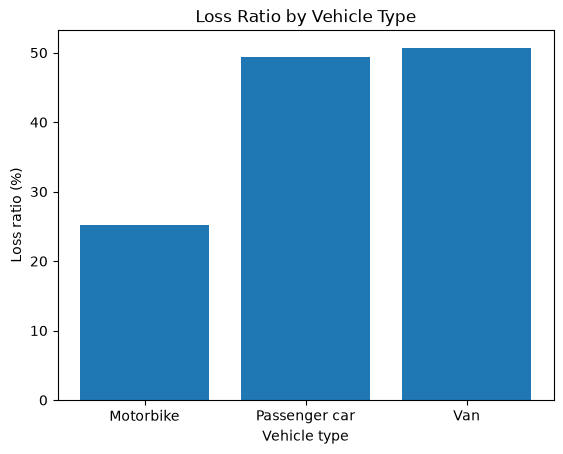

In [38]:
# Plot loss ratio by vehicle type
vehicle_loss_ratio = loss_ratio_by_type.drop("Agricultural vehicle")

plt.bar(
    vehicle_loss_ratio.index,
    vehicle_loss_ratio.values
)

plt.xlabel("Vehicle type")
plt.ylabel("Loss ratio (%)")
plt.title("Loss Ratio by Vehicle Type")

plt.show()

Agricultural vehicles are excluded because of their limited claim experience.

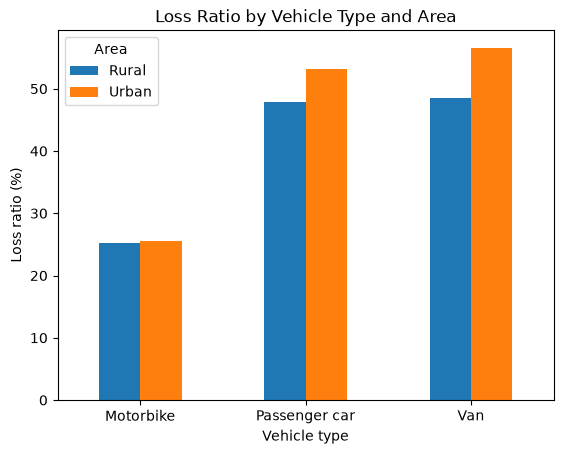

In [39]:
# Plot loss ratio by vehicle type and area
segment_loss_ratio = loss_ratio_by_segment

segment_loss_ratio = (
    segment_loss_ratio
    .drop("Agricultural vehicle")
    .unstack()
)

segment_loss_ratio.plot(kind="bar")

plt.xlabel("Vehicle type")
plt.ylabel("Loss ratio (%)")
plt.title("Loss Ratio by Vehicle Type and Area")
plt.xticks(rotation=0)

plt.show()

## Key Findings

The dataset contains 105,555 policy-periods, of which 18.61% recorded at least one claim. Total premium was 33.34 million and total claim cost was 16.21 million, resulting in an overall loss ratio of 48.61%. Claim frequency was 0.395 claims per policy-period. Average claim severity was 389.05 per claim.

Claim costs were highly concentrated. Among policy-periods with claims, the highest-loss 10% accounted for 57.33% of total claim costs.

Vans had the highest loss ratio at 50.67%, followed by passenger cars at 49.44% and motorbikes at 25.27%. Urban loss ratios were higher than rural loss ratios for passenger cars and vans, while motorbike loss ratios were nearly identical across areas.

Area was statistically associated with claim occurrence, but the association was very weak (Cramer's V = 0.029). Although urban policy-periods had claims more often than rural policy-periods, the difference was small.

## Limitations

The dataset represents one anonymized motor insurance portfolio, so the results may not generalize to other insurers or markets.

The analysis focuses on vehicle type and area and does not account for other policyholder or vehicle characteristics that may affect claim outcomes.

Agricultural vehicles had very limited claim experience, with only one claim-bearing policy-period, so they were excluded from claim comparisons.

The analysis identifies patterns in the data but does not establish cause and effect.